In [161]:
# Load df_netflix_user_behavior_encoded.csv
df_behavior = pd.read_csv('/content/df_netflix_user_behavior_encoded.csv', on_bad_lines='skip')
print('\n' + '-'*50 + '\n')
print('df_netflix_user_behavior_encoded.csv Info:')

# Convert relevant columns to numeric, coercing errors
for col in df_behavior.columns:
    if col != 'user_id': # user_id is an identifier, not a numeric feature
        df_behavior[col] = pd.to_numeric(df_behavior[col], errors='coerce')

df_behavior.info()
display(df_behavior.head())


--------------------------------------------------

df_netflix_user_behavior_encoded.csv Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     50000 non-null  object 
 1   age                         50000 non-null  int64  
 2   account_age_months          50000 non-null  int64  
 3   monthly_fee                 50000 non-null  float64
 4   devices_used                50000 non-null  int64  
 5   avg_watch_time_minutes      50000 non-null  int64  
 6   watch_sessions_per_week     50000 non-null  int64  
 7   binge_watch_sessions        50000 non-null  int64  
 8   completion_rate             50000 non-null  int64  
 9   rating_given                50000 non-null  float64
 10  content_interactions        50000 non-null  int64  
 11  recommendation_click_rate   50000 non-null  int64

,user_id,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,...,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller
0,U100000,56,17,15.99,1,220,17,3,60,1.7,...,False,False,False,False,False,False,False,False,True,False
1,U100001,46,20,12.99,2,76,15,4,71,4.6,...,False,False,True,False,True,False,False,False,False,False
2,U100002,32,25,15.99,2,215,6,13,33,2.0,...,False,False,True,True,False,False,False,False,False,False
3,U100003,60,37,12.99,3,280,4,9,58,1.2,...,False,True,False,False,False,False,False,False,False,False
4,U100004,25,23,12.99,3,261,15,9,64,1.3,...,True,False,False,False,False,False,True,False,False,False


In [162]:
# Load df_attachment_survey_cleaned.csv
df_survey = pd.read_csv('/content/df_attachment_survey_cleaned.csv')
print('\n' + '-'*50 + '\n')
print('df_attachment_survey_cleaned.csv Info:')
df_survey.info()
display(df_survey.head())


--------------------------------------------------

df_attachment_survey_cleaned.csv Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Age                                                                    15000 non-null  object 
 1   Gender                                                                 15000 non-null  object 
 2   Watched emotional movie in last 12 months                              15000 non-null  object 
 3   Movie/Book that affected you most recently                             15000 non-null  object 
 4   How many times watched                                                 15000 non-null  object 
 5   When watched most recently                                             15000 non-null  object 

,Age,Gender,Watched emotional movie in last 12 months,Movie/Book that affected you most recently,How many times watched,When watched most recently,The storytelling in this movie was emotionally powerful.,The story made me feel strong emotions.,The emotional moments felt genuine and realistic.,The characters' emotional experiences were clearly expressed.,The story focused strongly on characters' feelings and relationships.,I feel attached to the characters in this movie.,I still think about this movie or its characters after watching it.,I would like to watch this movie again in the future.,I would recommend this movie to others.,This movie has a special place in my memory compared to other movies.,Emotional Storytelling Score,Audience Attachment Score
0,24 or above,Male,Yes,An Affair to Remember,More than 3 times,1–6 months ago,4,4,3,4,3,4,3,3,2,3,3.6,3.0
1,18–20,Female,Yes,Everything Everywhere All at Once,1 time,1–6 months ago,4,4,2,2,4,3,3,5,4,4,3.2,3.8
2,24 or above,Female,Yes,Good Will Hunting,1 time,1–6 months ago,4,3,3,2,2,4,3,4,4,3,2.8,3.6
3,24 or above,Female,Yes,Atonement,1 time,Within last 1 month,4,3,4,3,4,2,5,5,3,4,3.6,3.8
4,24 or above,Female,Yes,Wild Strawberries,1 time,1–6 months ago,4,3,3,5,4,2,5,3,3,2,3.8,3.0


### Cleaning missing values in `df_titles`

In [163]:
import pandas as pd

# Load df_netflix_titles_processed.csv
df_titles = pd.read_csv('/content/df_netflix_titles_processed.csv')

# Fill missing values in 'director', 'cast', and 'country' with 'Unknown'
df_titles['director'].fillna('Unknown', inplace=True)
df_titles['cast'].fillna('Unknown', inplace=True)
df_titles['country'].fillna('Unknown', inplace=True)

# Fill missing values in 'rating' with the mode
mode_rating = df_titles['rating'].mode()[0]
df_titles['rating'].fillna(mode_rating, inplace=True)

# Fill missing values in 'date_added' with the mode
mode_date_added = df_titles['date_added'].mode()[0]
df_titles['date_added'].fillna(mode_date_added, inplace=True)

print('Missing values after cleaning df_titles:')
print(df_titles.isnull().sum())
display(df_titles.head())

Missing values after cleaning df_titles:
show_id                   0
type                      0
title                     0
director                  0
cast                      0
country                   0
date_added                0
release_year              0
rating                    0
listed_in                 0
description               0
movie_duration_minutes    0
tv_show_seasons           0
dtype: int64


/tmp/ipykernel_4830/1575903231.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_titles['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_4830/1575903231.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,movie_duration_minutes,tv_show_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",0,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,0,1
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",0,1
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,0,2


### Cleaning missing values in `df_behavior`

### Building the Recommendation Function

In [164]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Combine relevant text features into a single string for content-based filtering
df_titles['features'] = df_titles['director'] + ' ' + df_titles['cast'] + ' ' + df_titles['listed_in'] + ' ' + df_titles['description'] + ' ' + df_titles['type'] + ' ' + df_titles['rating']

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Construct the TF-IDF matrix by fitting and transforming the 'features' column
tfidf_matrix = tfidf.fit_transform(df_titles['features'])

# Compute the cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(df_titles.index, index=df_titles['title']).drop_duplicates()

def get_recommendations(title, cosine_sim=cosine_sim, df_titles=df_titles, indices=indices):
    # Get the index of the movie that matches the title
    idx = indices[title]

    # Get the pairwise similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar movies
    sim_scores = sim_scores[1:11] # Exclude the movie itself

    # Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar movies
    return df_titles['title'].iloc[movie_indices]

print('Recommendation function created.')
print('Try getting recommendations for "Spider-Man: Into the Spider-Verse":')
display(get_recommendations('Spider-Man: Into the Spider-Verse'))

Recommendation function created.
Try getting recommendations for "Spider-Man: Into the Spider-Verse":


,title
1439,History of Swear Words
4950,John Mulaney: New in Town
6027,A Bad Moms Christmas
4890,John Mulaney: Kid Gorgeous at Radio City
6244,Barely Lethal
274,Grace and Frankie
889,The Woman in the Window
1608,3 Days to Kill
2907,Term Life
8263,The D Train


### Calculating Content Similarity

In [165]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute the cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print('Cosine Similarity Matrix Shape:', cosine_sim.shape)

Cosine Similarity Matrix Shape: (8807, 8807)


### Vectorizing Content Features

In [166]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Construct the TF-IDF matrix by fitting and transforming the 'features' column
tfidf_matrix = tfidf.fit_transform(df_titles['features'])

print('TF-IDF matrix shape:', tfidf_matrix.shape)

TF-IDF matrix shape: (8807, 49947)


### Feature Engineering for `df_titles`

In [167]:
# Combine relevant text features into a single string for content-based filtering
df_titles['features'] = df_titles['director'] + ' ' + df_titles['cast'] + ' ' + df_titles['listed_in'] + ' ' + df_titles['description'] + ' ' + df_titles['type'] + ' ' + df_titles['rating']

print('df_titles with new features column:')
display(df_titles[['title', 'features']].head())

df_titles with new features column:


,title,features
0,Dick Johnson Is Dead,Kirsten Johnson Unknown Documentaries As her f...
1,Blood & Water,"Unknown Ama Qamata, Khosi Ngema, Gail Mabalane..."
2,Ganglands,"Julien Leclercq Sami Bouajila, Tracy Gotoas, S..."
3,Jailbirds New Orleans,"Unknown Unknown Docuseries, Reality TV Feuds, ..."
4,Kota Factory,"Unknown Mayur More, Jitendra Kumar, Ranjan Raj..."


In [168]:
# Identify numerical columns with missing values (excluding 'user_id')
numeric_cols_with_na = df_behavior.select_dtypes(include=['float64', 'int64']).columns

# Fill missing numerical values with the mean of their respective columns
for col in numeric_cols_with_na:
    if df_behavior[col].isnull().any():
        df_behavior[col].fillna(df_behavior[col].mean(), inplace=True)

print('Missing values after cleaning df_behavior:')
print(df_behavior.isnull().sum())
display(df_behavior.head())

Missing values after cleaning df_behavior:
user_id                       0
age                           0
account_age_months            0
monthly_fee                   0
devices_used                  0
avg_watch_time_minutes        0
watch_sessions_per_week       0
binge_watch_sessions          0
completion_rate               0
rating_given                  0
content_interactions          0
recommendation_click_rate     0
days_since_last_login         0
churned                       0
gender_Male                   0
gender_Other                  0
country_Brazil                0
country_Canada                0
country_France                0
country_Germany               0
country_India                 0
country_Japan                 0
country_Spain                 0
country_UK                    0
country_USA                   0
subscription_type_Premium     0
subscription_type_Standard    0
payment_method_Debit Card     0
payment_method_PayPal         0
payment_method_UPI           

,user_id,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,...,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller
0,U100000,56,17,15.99,1,220,17,3,60,1.7,...,False,False,False,False,False,False,False,False,True,False
1,U100001,46,20,12.99,2,76,15,4,71,4.6,...,False,False,True,False,True,False,False,False,False,False
2,U100002,32,25,15.99,2,215,6,13,33,2.0,...,False,False,True,True,False,False,False,False,False,False
3,U100003,60,37,12.99,3,280,4,9,58,1.2,...,False,True,False,False,False,False,False,False,False,False
4,U100004,25,23,12.99,3,261,15,9,64,1.3,...,True,False,False,False,False,False,True,False,False,False


### Building a Hybrid Recommendation Function

In [169]:
def get_user_top_genre(user_id, df_behavior=df_behavior):
    user_row = df_behavior[df_behavior['user_id'] == user_id]
    if user_row.empty:
        return None

    genre_cols = [col for col in df_behavior.columns if col.startswith('favorite_genre_')]
    if not genre_cols:
        return None

    # Get the genre with the highest preference score for the user
    top_genre_score = user_row[genre_cols].iloc[0].max()
    if pd.isna(top_genre_score) or top_genre_score == 0:
        return None # No clear favorite genre

    top_genres = user_row[genre_cols].iloc[0][user_row[genre_cols].iloc[0] == top_genre_score].index.tolist()
    # Extract the genre name from 'favorite_genre_GenreName'
    top_genres = [genre.replace('favorite_genre_', '') for genre in top_genres]
    return top_genres[0] if top_genres else None # Return the first top genre if multiple, or None

def get_age_appropriate_ratings(age):
    if age < 13:
        return ['TV-Y', 'TV-G', 'G']
    elif age < 14:
        return ['TV-Y', 'TV-G', 'TV-PG', 'G', 'PG']
    elif age < 17:
        return ['TV-Y', 'TV-G', 'TV-PG', 'TV-14', 'G', 'PG', 'PG-13']
    else:
        return ['TV-Y', 'TV-G', 'TV-PG', 'TV-14', 'TV-MA', 'G', 'PG', 'PG-13', 'R', 'NC-17']


def get_hybrid_recommendations(user_id, num_recommendations=10, df_titles=df_titles, df_behavior=df_behavior, cosine_sim=cosine_sim, indices=indices):
    user_row = df_behavior[df_behavior['user_id'] == user_id]
    if user_row.empty:
        print(f"User ID {user_id} not found.")
        return pd.Series()

    user_age = user_row['age'].iloc[0]
    user_top_genre = get_user_top_genre(user_id, df_behavior)

    if user_top_genre is None:
        print(f"Could not determine top genre for user {user_id}. Reverting to general content recommendations for a popular movie.")
        # Fallback: pick a popular movie to get general content recommendations
        seed_title = df_titles.loc[df_titles['title'] == 'Spider-Man: Into the Spider-Verse', 'title'].iloc[0]
    else:
        print(f"User {user_id} (age {int(user_age)}) prefers genre: {user_top_genre}")
        # Find titles in the user's top genre
        genre_titles = df_titles[df_titles['listed_in'].str.contains(user_top_genre, case=False, na=False)]
        if genre_titles.empty:
            print(f"No titles found for genre '{user_top_genre}'. Reverting to general content recommendations for a popular movie.")
            seed_title = df_titles.loc[df_titles['title'] == 'Spider-Man: Into the Spider-Verse', 'title'].iloc[0]
        else:
            # For simplicity, pick a random title from the user's preferred genre as a seed.
            # In a real system, this would be a title the user has watched or rated highly.
            seed_title = genre_titles.sample(1)['title'].iloc[0]
            print(f"Using '{seed_title}' as a seed for recommendations.")

    # Get initial content-based recommendations
    content_recs = get_recommendations(seed_title, cosine_sim, df_titles, indices)

    # Filter by age appropriateness
    age_appropriate_ratings = get_age_appropriate_ratings(user_age)
    filtered_recs = df_titles[df_titles['title'].isin(content_recs) & df_titles['rating'].isin(age_appropriate_ratings)]['title']

    # If filtering removed all recommendations, return the original content recommendations (with a warning)
    if filtered_recs.empty and not content_recs.empty:
        print("Age filtering removed all recommendations. Returning original content recommendations.")
        return content_recs.head(num_recommendations)
    elif filtered_recs.empty:
        return pd.Series()

    # If the user has a top genre, prioritize recommendations that also belong to that genre
    if user_top_genre:
        # Boost items matching the user's top genre
        final_recs_with_genre_boost = filtered_recs.tolist()
        other_recs = [rec for rec in content_recs if rec not in final_recs_with_genre_boost]

        # Add other recommendations, prioritizing those matching the genre first
        genre_matching_other_recs = df_titles[df_titles['title'].isin(other_recs) &
                                            df_titles['listed_in'].str.contains(user_top_genre, case=False, na=False)]['title']

        non_genre_matching_other_recs = [rec for rec in other_recs if rec not in genre_matching_other_recs.tolist()]

        # Combine, prioritizing filtered_recs (age-appropriate and already genre-aligned if possible)
        # followed by other content-similar recommendations that match genre, then the rest.
        final_recommendations = pd.concat([filtered_recs,
                                           genre_matching_other_recs,
                                           pd.Series(non_genre_matching_other_recs)]).drop_duplicates()
    else:
        final_recommendations = filtered_recs

    return final_recommendations.head(num_recommendations)

print('Hybrid recommendation function created.')
print('Trying recommendations for User U100000 (age 56):')
display(get_hybrid_recommendations('U100000'))

print('\nTrying recommendations for User U100005 (age 15):')
display(get_hybrid_recommendations('U100005'))

Hybrid recommendation function created.
Trying recommendations for User U100000 (age 56):
User U100000 (age 56) prefers genre: Sci-Fi
Using 'Star Trek: The Next Generation' as a seed for recommendations.


,0
594,Star Trek
2156,Tiny Creatures
2190,The Umbrella Academy
3505,Inside Bill's Brain: Decoding Bill Gates
5244,Star Trek: Enterprise
5650,Star Trek: Deep Space Nine
6600,Devil's Gate
2135,The Legend of Korra
3246,The Dragon Prince
0,Stretch Armstrong & the Flex Fighters



Trying recommendations for User U100005 (age 15):
User U100005 (age 38) prefers genre: Documentary
No titles found for genre 'Documentary'. Reverting to general content recommendations for a popular movie.


,0
274,Grace and Frankie
889,The Woman in the Window
1439,History of Swear Words
1608,3 Days to Kill
2907,Term Life
4890,John Mulaney: Kid Gorgeous at Radio City
4950,John Mulaney: New in Town
6027,A Bad Moms Christmas
6244,Barely Lethal
8263,The D Train


### Feature Engineering for User Profiles

In [170]:
# Select relevant user behavior features for model training
user_features = [
    'user_id',
    'age',
    'account_age_months',
    'monthly_fee',
    'devices_used',
    'avg_watch_time_minutes',
    'watch_sessions_per_week',
    'binge_watch_sessions',
    'completion_rate',
    'rating_given',
    'content_interactions',
    'recommendation_click_rate',
    'days_since_last_login',
    'churned',
    'gender_Male',
    'gender_Other'
] + [col for col in df_behavior.columns if col.startswith('country_') or col.startswith('subscription_type_') or col.startswith('payment_method_') or col.startswith('primary_device_') or col.startswith('favorite_genre_')]

df_user_features = df_behavior[user_features].copy()

# Ensure all selected features are numeric, coercing errors will turn non-numeric into NaN, which should have been handled by previous cleaning.
for col in df_user_features.columns:
    if col != 'user_id':
        df_user_features[col] = pd.to_numeric(df_user_features[col], errors='coerce')

# Drop user_id for model training, but keep it as index for identification
df_user_features.set_index('user_id', inplace=True)

print('User Features DataFrame:')
df_user_features.info()
display(df_user_features.head())

User Features DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, U100000 to U149999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         50000 non-null  int64  
 1   account_age_months          50000 non-null  int64  
 2   monthly_fee                 50000 non-null  float64
 3   devices_used                50000 non-null  int64  
 4   avg_watch_time_minutes      50000 non-null  int64  
 5   watch_sessions_per_week     50000 non-null  int64  
 6   binge_watch_sessions        50000 non-null  int64  
 7   completion_rate             50000 non-null  int64  
 8   rating_given                50000 non-null  float64
 9   content_interactions        50000 non-null  int64  
 10  recommendation_click_rate   50000 non-null  int64  
 11  days_since_last_login       50000 non-null  int64  
 12  churned                     50000 non-null  int64  
 13  gen

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,...,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller
user_id,,,,,,,,,,,,,,,,,,,,,
U100000,56,17,15.99,1,220,17,3,60,1.7,5,...,False,False,False,False,False,False,False,False,True,False
U100001,46,20,12.99,2,76,15,4,71,4.6,7,...,False,False,True,False,True,False,False,False,False,False
U100002,32,25,15.99,2,215,6,13,33,2.0,27,...,False,False,True,True,False,False,False,False,False,False
U100003,60,37,12.99,3,280,4,9,58,1.2,9,...,False,True,False,False,False,False,False,False,False,False
U100004,25,23,12.99,3,261,15,9,64,1.3,49,...,True,False,False,False,False,False,True,False,False,False


### User Clustering for Personalization

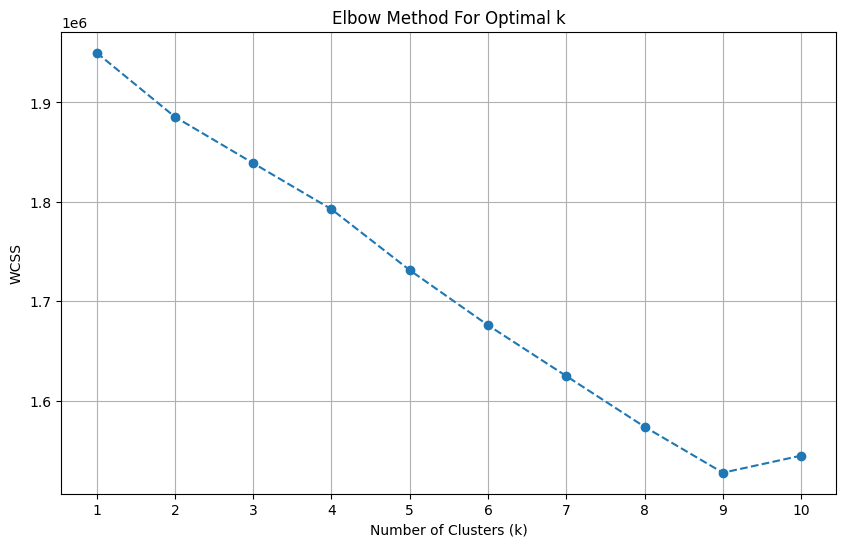

The Elbow Method plot is displayed above. Please examine the plot to determine an appropriate number of clusters (k). A common approach is to look for the 'elbow point' where the rate of decrease in WCSS (Within-Cluster Sum of Squares) sharply changes.


In [171]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Scale the user features
scaler = StandardScaler()
df_user_features_scaled = scaler.fit_transform(df_user_features)

# Determine the optimal number of clusters using the Elbow Method
wcss = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init suppresses warning
    kmeans.fit(df_user_features_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("The Elbow Method plot is displayed above. Please examine the plot to determine an appropriate number of clusters (k). A common approach is to look for the 'elbow point' where the rate of decrease in WCSS (Within-Cluster Sum of Squares) sharply changes.")

In [172]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (40000, 42)
Shape of X_test: (10000, 42)
Shape of y_train: (40000,)
Shape of y_test: (10000,)


In [173]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest Classifier with balanced data and new features
rf_model_new_features = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_new_features.fit(X_train_res_new, y_train_res_new)

print('Random Forest Classifier trained successfully with new balanced features.')

Random Forest Classifier trained successfully with new balanced features.


In [174]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# --- Re-execute Feature Engineering for df_behavior (from f0e920fb) ---
# Create 'Watch_Time_Per_Device'
df_behavior['watch_time_per_device'] = np.where(
    df_behavior['devices_used'] == 0,
    0, # Assign 0 if devices_used is 0
    df_behavior['avg_watch_time_minutes'] / df_behavior['devices_used']
)

# Create 'Engagement_Ratio'
df_behavior['engagement_ratio'] = np.where(
    df_behavior['watch_sessions_per_week'] == 0,
    0, # Assign 0 if watch_sessions_per_week is 0
    df_behavior['content_interactions'] / df_behavior['watch_sessions_per_week']
)

# Create 'Value_Ratio'
df_behavior['value_ratio'] = np.where(
    df_behavior['monthly_fee'] == 0,
    0, # Assign 0 if monthly_fee is 0
    df_behavior['avg_watch_time_minutes'] / df_behavior['monthly_fee']
)

# Create 'Binge_Watch_Frequency'
df_behavior['binge_watch_frequency'] = np.where(
    df_behavior['watch_sessions_per_week'] == 0,
    0, # Assign 0 if watch_sessions_per_week is 0
    df_behavior['binge_watch_sessions'] / df_behavior['watch_sessions_per_week']
)


# --- Re-execute Selection of Features and Target (from f0150368 and 979e46f7) ---
target_variable = 'churned'
# Define feature_columns_new to include all features except 'user_id', 'churned', and 'cluster'
feature_columns_new = [col for col in df_behavior.columns if col not in ['user_id', target_variable, 'cluster']]

X_new = df_behavior[feature_columns_new]
y_new = df_behavior[target_variable].astype(int) # Convert target to integer type

print('First 5 rows of X_new (after re-creation):')
display(X_new.head())
print('\nFirst 5 rows of y_new (after re-creation):')
display(y_new.head())

# --- Re-execute Train-Test Split (from 2f1bae66) ---
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42, stratify=y_new)

print('\nShape of X_train_new (after re-creation):', X_train_new.shape)
print('Shape of X_test_new (after re-creation):', X_test_new.shape)
print('Shape of y_train_new (after re-creation):', y_train_new.shape)
print('Shape of y_test_new (after re-creation):', y_test_new.shape)

# --- Re-execute SMOTE for balancing training data (from b0278f34) ---
sm = SMOTE(random_state=42)
X_train_res_new, y_train_res_new = sm.fit_resample(X_train_new, y_train_new)

print('\nOriginal training target class distribution (re-created):')
print(y_train_new.value_counts())
print('\nResampled training target class distribution (re-created):')
print(y_train_res_new.value_counts())

print('\nAll necessary variables (X_train_res_new, y_train_res_new, etc.) have been re-created.')

First 5 rows of X_new (after re-creation):


,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,...,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller,watch_time_per_device,engagement_ratio,value_ratio,binge_watch_frequency
0,56,17,15.99,1,220,17,3,60,1.7,5,...,False,False,False,False,True,False,220.000000,0.294118,13.758599,0.176471
1,46,20,12.99,2,76,15,4,71,4.6,7,...,True,False,False,False,False,False,38.000000,0.466667,5.850654,0.266667
2,32,25,15.99,2,215,6,13,33,2.0,27,...,False,False,False,False,False,False,107.500000,4.500000,13.445904,2.166667
3,60,37,12.99,3,280,4,9,58,1.2,9,...,False,False,False,False,False,False,93.333333,2.250000,21.555042,2.250000
4,25,23,12.99,3,261,15,9,64,1.3,49,...,False,False,True,False,False,False,87.000000,3.266667,20.092379,0.600000



First 5 rows of y_new (after re-creation):


,churned
0,0
1,0
2,0
3,0
4,0



Shape of X_train_new (after re-creation): (40000, 42)
Shape of X_test_new (after re-creation): (10000, 42)
Shape of y_train_new (after re-creation): (40000,)
Shape of y_test_new (after re-creation): (10000,)

Original training target class distribution (re-created):
churned
0    32029
1     7971
Name: count, dtype: int64

Resampled training target class distribution (re-created):
churned
1    32029
0    32029
Name: count, dtype: int64

All necessary variables (X_train_res_new, y_train_res_new, etc.) have been re-created.


In [175]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import pandas as pd

# Make predictions on the test set using the Random Forest model with new features
y_pred_rf_new_features = rf_model_new_features.predict(X_test_new)
y_proba_rf_new_features = rf_model_new_features.predict_proba(X_test_new)[:, 1]

print('Random Forest Model Performance on Test Set (with balanced training data and new features):')
print('Accuracy:', accuracy_score(y_test_new, y_pred_rf_new_features))

print('\nClassification Report:')
print(classification_report(y_test_new, y_pred_rf_new_features))

print('\nConfusion Matrix:')
conf_matrix_rf_new_features = confusion_matrix(y_test_new, y_pred_rf_new_features)
display(pd.DataFrame(conf_matrix_rf_new_features, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

# Calculate AUC-ROC score
auc_roc_rf_new_features = roc_auc_score(y_test_new, y_proba_rf_new_features)
print(f'\nAUC-ROC Score: {auc_roc_rf_new_features:.4f}')

Random Forest Model Performance on Test Set (with balanced training data and new features):
Accuracy: 0.7968

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      8007
           1       0.13      0.00      0.01      1993

    accuracy                           0.80     10000
   macro avg       0.47      0.50      0.45     10000
weighted avg       0.67      0.80      0.71     10000


Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,7961,46
Actual Churn,1986,7



AUC-ROC Score: 0.4895


In [176]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest Classifier with balanced data and new features
rf_model_new_features = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_new_features.fit(X_train_res_new, y_train_res_new)

print('Random Forest Classifier trained successfully with new balanced features.')

Random Forest Classifier trained successfully with new balanced features.


In [177]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import pandas as pd

# Make predictions on the test set using the Random Forest model with new features
y_pred_rf_new_features = rf_model_new_features.predict(X_test_new)
y_proba_rf_new_features = rf_model_new_features.predict_proba(X_test_new)[:, 1]

print('Random Forest Model Performance on Test Set (with balanced training data and new features):')
print('Accuracy:', accuracy_score(y_test_new, y_pred_rf_new_features))

print('\nClassification Report:')
print(classification_report(y_test_new, y_pred_rf_new_features))

print('\nConfusion Matrix:')
conf_matrix_rf_new_features = confusion_matrix(y_test_new, y_pred_rf_new_features)
display(pd.DataFrame(conf_matrix_rf_new_features, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

# Calculate AUC-ROC score
auc_roc_rf_new_features = roc_auc_score(y_test_new, y_proba_rf_new_features)
print(f'\nAUC-ROC Score: {auc_roc_rf_new_features:.4f}')

Random Forest Model Performance on Test Set (with balanced training data and new features):
Accuracy: 0.7968

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      8007
           1       0.13      0.00      0.01      1993

    accuracy                           0.80     10000
   macro avg       0.47      0.50      0.45     10000
weighted avg       0.67      0.80      0.71     10000


Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,7961,46
Actual Churn,1986,7



AUC-ROC Score: 0.4895


In [178]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest Classifier with balanced data and new features
rf_model_new_features = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_new_features.fit(X_train_res_new, y_train_res_new)

print('Random Forest Classifier trained successfully with new balanced features.')

Random Forest Classifier trained successfully with new balanced features.


In [179]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import pandas as pd

# Make predictions on the test set using the Random Forest model with new features
y_pred_rf_new_features = rf_model_new_features.predict(X_test_new)
y_proba_rf_new_features = rf_model_new_features.predict_proba(X_test_new)[:, 1]

print('Random Forest Model Performance on Test Set (with balanced training data and new features):')
print('Accuracy:', accuracy_score(y_test_new, y_pred_rf_new_features))

print('\nClassification Report:')
print(classification_report(y_test_new, y_pred_rf_new_features))

print('\nConfusion Matrix:')
conf_matrix_rf_new_features = confusion_matrix(y_test_new, y_pred_rf_new_features)
display(pd.DataFrame(conf_matrix_rf_new_features, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

# Calculate AUC-ROC score
auc_roc_rf_new_features = roc_auc_score(y_test_new, y_proba_rf_new_features)
print(f'\nAUC-ROC Score: {auc_roc_rf_new_features:.4f}')

Random Forest Model Performance on Test Set (with balanced training data and new features):
Accuracy: 0.7968

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      8007
           1       0.13      0.00      0.01      1993

    accuracy                           0.80     10000
   macro avg       0.47      0.50      0.45     10000
weighted avg       0.67      0.80      0.71     10000


Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,7961,46
Actual Churn,1986,7



AUC-ROC Score: 0.4895


In [180]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest Classifier with balanced data and new features
rf_model_new_features = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_new_features.fit(X_train_res_new, y_train_res_new)

print('Random Forest Classifier trained successfully with new balanced features.')

Random Forest Classifier trained successfully with new balanced features.


In [181]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import pandas as pd

# Make predictions on the test set using the Random Forest model with new features
y_pred_rf_new_features = rf_model_new_features.predict(X_test_new)
y_proba_rf_new_features = rf_model_new_features.predict_proba(X_test_new)[:, 1]

print('Random Forest Model Performance on Test Set (with balanced training data and new features):')
print('Accuracy:', accuracy_score(y_test_new, y_pred_rf_new_features))

print('\nClassification Report:')
print(classification_report(y_test_new, y_pred_rf_new_features))

print('\nConfusion Matrix:')
conf_matrix_rf_new_features = confusion_matrix(y_test_new, y_pred_rf_new_features)
display(pd.DataFrame(conf_matrix_rf_new_features, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

# Calculate AUC-ROC score
auc_roc_rf_new_features = roc_auc_score(y_test_new, y_proba_rf_new_features)
print(f'\nAUC-ROC Score: {auc_roc_rf_new_features:.4f}')

Random Forest Model Performance on Test Set (with balanced training data and new features):
Accuracy: 0.7968

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      8007
           1       0.13      0.00      0.01      1993

    accuracy                           0.80     10000
   macro avg       0.47      0.50      0.45     10000
weighted avg       0.67      0.80      0.71     10000


Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,7961,46
Actual Churn,1986,7



AUC-ROC Score: 0.4895


In [182]:
import numpy as np

# Create 'Watch_Time_Per_Device'
# Handle potential division by zero by replacing 0 with 1 for devices_used in calculation, then replacing resulting inf with 0
df_behavior['watch_time_per_device'] = np.where(
    df_behavior['devices_used'] == 0,
    0, # Assign 0 if devices_used is 0
    df_behavior['avg_watch_time_minutes'] / df_behavior['devices_used']
)

# Create 'Engagement_Ratio'
df_behavior['engagement_ratio'] = np.where(
    df_behavior['watch_sessions_per_week'] == 0,
    0, # Assign 0 if watch_sessions_per_week is 0
    df_behavior['content_interactions'] / df_behavior['watch_sessions_per_week']
)

# Create 'Value_Ratio'
df_behavior['value_ratio'] = np.where(
    df_behavior['monthly_fee'] == 0,
    0, # Assign 0 if monthly_fee is 0
    df_behavior['avg_watch_time_minutes'] / df_behavior['monthly_fee']
)

# Create 'Binge_Watch_Frequency'
df_behavior['binge_watch_frequency'] = np.where(
    df_behavior['watch_sessions_per_week'] == 0,
    0, # Assign 0 if watch_sessions_per_week is 0
    df_behavior['binge_watch_sessions'] / df_behavior['watch_sessions_per_week']
)

print('New features added to df_behavior:')
display(df_behavior[['user_id', 'watch_time_per_device', 'engagement_ratio', 'value_ratio', 'binge_watch_frequency']].head())

New features added to df_behavior:


,user_id,watch_time_per_device,engagement_ratio,value_ratio,binge_watch_frequency
0,U100000,220.000000,0.294118,13.758599,0.176471
1,U100001,38.000000,0.466667,5.850654,0.266667
2,U100002,107.500000,4.500000,13.445904,2.166667
3,U100003,93.333333,2.250000,21.555042,2.250000
4,U100004,87.000000,3.266667,20.092379,0.600000


In [183]:
# Update feature_columns to include the new features
feature_columns_new = [col for col in df_behavior.columns if col not in ['user_id', target_variable, 'cluster']]

X_new = df_behavior[feature_columns_new]
y_new = df_behavior[target_variable].astype(int) # Convert target to integer type

print('First 5 rows of new feature matrix X_new:')
display(X_new.head())

print('\nFirst 5 rows of new target vector y_new:')
display(y_new.head())

First 5 rows of new feature matrix X_new:


,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,...,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller,watch_time_per_device,engagement_ratio,value_ratio,binge_watch_frequency
0,56,17,15.99,1,220,17,3,60,1.7,5,...,False,False,False,False,True,False,220.000000,0.294118,13.758599,0.176471
1,46,20,12.99,2,76,15,4,71,4.6,7,...,True,False,False,False,False,False,38.000000,0.466667,5.850654,0.266667
2,32,25,15.99,2,215,6,13,33,2.0,27,...,False,False,False,False,False,False,107.500000,4.500000,13.445904,2.166667
3,60,37,12.99,3,280,4,9,58,1.2,9,...,False,False,False,False,False,False,93.333333,2.250000,21.555042,2.250000
4,25,23,12.99,3,261,15,9,64,1.3,49,...,False,False,True,False,False,False,87.000000,3.266667,20.092379,0.600000



First 5 rows of new target vector y_new:


,churned
0,0
1,0
2,0
3,0
4,0


In [184]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets using the new features
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42, stratify=y_new)

print('Shape of X_train_new:', X_train_new.shape)
print('Shape of X_test_new:', X_test_new.shape)
print('Shape of y_train_new:', y_train_new.shape)
print('Shape of y_test_new:', y_test_new.shape)

Shape of X_train_new: (40000, 42)
Shape of X_test_new: (10000, 42)
Shape of y_train_new: (40000,)
Shape of y_test_new: (10000,)


In [185]:
from imblearn.over_sampling import SMOTE

print('Original training target class distribution (new features):')
print(y_train_new.value_counts())

sm = SMOTE(random_state=42)
X_train_res_new, y_train_res_new = sm.fit_resample(X_train_new, y_train_new)

print('\nResampled training target class distribution (new features):')
print(y_train_res_new.value_counts())

print('Training data balanced using SMOTE for new features.')

Original training target class distribution (new features):
churned
0    32029
1     7971
Name: count, dtype: int64

Resampled training target class distribution (new features):
churned
1    32029
0    32029
Name: count, dtype: int64
Training data balanced using SMOTE for new features.


In [186]:
from sklearn.linear_model import LogisticRegression

# Re-initialize and train the Logistic Regression model with new balanced data
log_reg_model_balanced_new_features = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000) # Increased max_iter for convergence
log_reg_model_balanced_new_features.fit(X_train_res_new, y_train_res_new)

print('Logistic Regression model trained successfully with new balanced features.')

Logistic Regression model trained successfully with new balanced features.


In [187]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import pandas as pd

# Make predictions on the test set using the balanced model with new features
y_pred_balanced_new_features = log_reg_model_balanced_new_features.predict(X_test_new)
y_proba_balanced_new_features = log_reg_model_balanced_new_features.predict_proba(X_test_new)[:, 1]

print('Model Performance on Test Set (with balanced training data and new features):')
print('Accuracy:', accuracy_score(y_test_new, y_pred_balanced_new_features))

print('\nClassification Report:')
print(classification_report(y_test_new, y_pred_balanced_new_features))

print('\nConfusion Matrix:')
conf_matrix_balanced_new_features = confusion_matrix(y_test_new, y_pred_balanced_new_features)
display(pd.DataFrame(conf_matrix_balanced_new_features, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

# Calculate AUC-ROC score
auc_roc_balanced_new_features = roc_auc_score(y_test_new, y_proba_balanced_new_features)
print(f'\nAUC-ROC Score: {auc_roc_balanced_new_features:.4f}')

Model Performance on Test Set (with balanced training data and new features):
Accuracy: 0.7767

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      8007
           1       0.16      0.03      0.05      1993

    accuracy                           0.78     10000
   macro avg       0.48      0.50      0.46     10000
weighted avg       0.67      0.78      0.71     10000


Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,7711,296
Actual Churn,1937,56



AUC-ROC Score: 0.4971


In [188]:
# Ensure feature_columns only contains columns present in df_behavior
feature_columns = [col for col in feature_columns if col in df_behavior.columns]

X = df_behavior[feature_columns]
y = df_behavior[target_variable].astype(int) # Convert target to integer type

print('First 5 rows of feature matrix X:')
display(X.head())

print('\nFirst 5 rows of target vector y:')
display(y.head())

First 5 rows of feature matrix X:


,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,...,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller,watch_time_per_device,engagement_ratio,value_ratio,binge_watch_frequency
0,56,17,15.99,1,220,17,3,60,1.7,5,...,False,False,False,False,True,False,220.000000,0.294118,13.758599,0.176471
1,46,20,12.99,2,76,15,4,71,4.6,7,...,True,False,False,False,False,False,38.000000,0.466667,5.850654,0.266667
2,32,25,15.99,2,215,6,13,33,2.0,27,...,False,False,False,False,False,False,107.500000,4.500000,13.445904,2.166667
3,60,37,12.99,3,280,4,9,58,1.2,9,...,False,False,False,False,False,False,93.333333,2.250000,21.555042,2.250000
4,25,23,12.99,3,261,15,9,64,1.3,49,...,False,False,True,False,False,False,87.000000,3.266667,20.092379,0.600000



First 5 rows of target vector y:


,churned
0,0
1,0
2,0
3,0
4,0


In [189]:
target_variable = 'churned'
feature_columns = [col for col in df_behavior.columns if col not in ['user_id', target_variable]]

print(f"Target variable: {target_variable}")
print(f"Number of feature columns: {len(feature_columns)}")
print("First 5 feature columns:")
display(feature_columns[:5])

Target variable: churned
Number of feature columns: 42
First 5 feature columns:


['age',
 'account_age_months',
 'monthly_fee',
 'devices_used',
 'avg_watch_time_minutes']

In [190]:
k_optimal = 4 # Choosing k=4 based on the Elbow Method plot observation

# Before applying KMeans and setting clusters, ensure df_user_features has unique user_id as index.
# If df_behavior has multiple entries per user, we need to aggregate.
# Assuming numerical features can be averaged to represent a user profile.

# First, re-select user_features for aggregation, ensuring 'user_id' is excluded from the aggregated columns
user_features_cols_to_agg = [col for col in df_behavior.columns if col not in ['user_id'] and (
    col.startswith('age') or col.startswith('account_age_months') or col.startswith('monthly_fee') or
    col.startswith('devices_used') or col.startswith('avg_watch_time_minutes') or
    col.startswith('watch_sessions_per_week') or col.startswith('binge_watch_sessions') or
    col.startswith('completion_rate') or col.startswith('rating_given') or
    col.startswith('content_interactions') or col.startswith('recommendation_click_rate') or
    col.startswith('days_since_last_login') or col.startswith('churned') or
    col.startswith('gender_') or col.startswith('country_') or
    col.startswith('subscription_type_') or col.startswith('payment_method_') or
    col.startswith('primary_device_') or col.startswith('favorite_genre_'))]

# Aggregate df_behavior to create unique user profiles based on the mean of their features
df_user_features_agg = df_behavior.groupby('user_id')[user_features_cols_to_agg].mean()

# Re-assign df_user_features to this aggregated DataFrame
df_user_features = df_user_features_agg

# Now, scale the aggregated user features
scaler = StandardScaler()
df_user_features_scaled = scaler.fit_transform(df_user_features)

kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
df_user_features['cluster'] = kmeans.fit_predict(df_user_features_scaled)

# Map the cluster assignments back to the original df_behavior DataFrame (or its user_id column)
df_behavior['cluster'] = df_behavior['user_id'].map(df_user_features['cluster'])

print(f"Users clustered into {k_optimal} groups.")
display(df_user_features.head())

Users clustered into 4 groups.


,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,...,primary_device_Smart TV,primary_device_Tablet,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller,cluster
user_id,,,,,,,,,,,,,,,,,,,,,
U100000,56.0,17.0,15.99,1.0,220.0,17.0,3.0,60.0,1.7,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
U100001,46.0,20.0,12.99,2.0,76.0,15.0,4.0,71.0,4.6,7.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2
U100002,32.0,25.0,15.99,2.0,215.0,6.0,13.0,33.0,2.0,27.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2
U100003,60.0,37.0,12.99,3.0,280.0,4.0,9.0,58.0,1.2,9.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
U100004,25.0,23.0,12.99,3.0,261.0,15.0,9.0,64.0,1.3,49.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0


### Analyzing User Clusters

In [191]:
# Analyze cluster characteristics
cluster_centers_original_scale = scaler.inverse_transform(kmeans.cluster_centers_)
df_cluster_centers = pd.DataFrame(cluster_centers_original_scale, columns=df_user_features.drop('cluster', axis=1).columns)
df_cluster_centers.index.name = 'Cluster'

print("Cluster Centers (Original Scale):")
display(df_cluster_centers)

# Identify dominant genres for each cluster
genre_cols = [col for col in df_user_features.columns if col.startswith('favorite_genre_')]
cluster_genre_preferences = df_user_features.groupby('cluster')[genre_cols].mean()

print("\nDominant Genres per Cluster (Average Preference Score):")
for cluster_id in range(k_optimal):
    top_genre = cluster_genre_preferences.loc[cluster_id].idxmax().replace('favorite_genre_', '')
    print(f"Cluster {cluster_id}: Top Genre - {top_genre}")

Cluster Centers (Original Scale):


,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,...,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller
Cluster,,,,,,,,,,,,,,,,,,,,,
0,41.251173,29.526779,12.337342,1.996091,154.094996,9.920250,7.036943,63.754887,2.995856,24.209734,...,0.251759,0.246286,0.244918,0.131157,0.129593,0.125880,0.123729,0.124707,0.117475,0.124511
1,41.013061,29.900347,12.301339,2.003315,155.334305,10.003874,6.996725,64.488397,2.997480,24.327395,...,0.251148,0.252506,0.245357,0.065383,0.133482,0.133403,0.134042,0.134201,0.132604,0.134840
2,40.717712,30.140161,12.354655,1.994692,155.766857,10.016709,7.029290,65.028897,3.019815,24.270100,...,0.244938,0.247297,0.259485,0.129349,0.126794,0.131119,0.116572,0.127384,0.122272,0.123255
3,40.917751,29.857927,12.345014,1.994648,154.301152,9.971003,6.991192,64.708875,3.006728,24.316734,...,0.254946,0.252168,0.245799,0.223103,0.115312,0.105149,0.111179,0.110840,0.111518,0.109553



Dominant Genres per Cluster (Average Preference Score):
Cluster 0: Top Genre - Comedy
Cluster 1: Top Genre - Thriller
Cluster 2: Top Genre - Drama
Cluster 3: Top Genre - Comedy


### Building a Cluster-Enhanced Hybrid Recommendation Function

In [192]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import pandas as pd

# Make predictions on the test set using the model with balanced class weights
y_pred_rf_balanced_weights = rf_model_balanced_weights.predict(X_test_new)
y_proba_rf_balanced_weights = rf_model_balanced_weights.predict_proba(X_test_new)[:, 1]

print('Random Forest Model Performance on Test Set (with balanced class weights and new features):')
print('Accuracy:', accuracy_score(y_test_new, y_pred_rf_balanced_weights))

print('\nClassification Report:')
print(classification_report(y_test_new, y_pred_rf_balanced_weights))

print('\nConfusion Matrix:')
conf_matrix_rf_balanced_weights = confusion_matrix(y_test_new, y_pred_rf_balanced_weights)
display(pd.DataFrame(conf_matrix_rf_balanced_weights, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

# Calculate AUC-ROC score
auc_roc_rf_balanced_weights = roc_auc_score(y_test_new, y_proba_rf_balanced_weights)
print(f'\nAUC-ROC Score: {auc_roc_rf_balanced_weights:.4f}')

Random Forest Model Performance on Test Set (with balanced class weights and new features):
Accuracy: 0.7968

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      8007
           1       0.13      0.00      0.01      1993

    accuracy                           0.80     10000
   macro avg       0.47      0.50      0.45     10000
weighted avg       0.67      0.80      0.71     10000


Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,7961,46
Actual Churn,1986,7



AUC-ROC Score: 0.4895


In [193]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest Classifier with class_weight='balanced'
# This parameter automatically adjusts weights inversely proportional to class frequencies
rf_model_balanced_weights = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_model_balanced_weights.fit(X_train_res_new, y_train_res_new)

print('Random Forest Classifier trained successfully with balanced class weights.')

Random Forest Classifier trained successfully with balanced class weights.


In [194]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import pandas as pd

# Make predictions on the test set using the model with balanced class weights
y_pred_rf_balanced_weights = rf_model_balanced_weights.predict(X_test_new)
y_proba_rf_balanced_weights = rf_model_balanced_weights.predict_proba(X_test_new)[:, 1]

print('Random Forest Model Performance on Test Set (with balanced class weights and new features):')
print('Accuracy:', accuracy_score(y_test_new, y_pred_rf_balanced_weights))

print('\nClassification Report:')
print(classification_report(y_test_new, y_pred_rf_balanced_weights))

print('\nConfusion Matrix:')
conf_matrix_rf_balanced_weights = confusion_matrix(y_test_new, y_pred_rf_balanced_weights)
display(pd.DataFrame(conf_matrix_rf_balanced_weights, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

# Calculate AUC-ROC score
auc_roc_rf_balanced_weights = roc_auc_score(y_test_new, y_proba_rf_balanced_weights)
print(f'\nAUC-ROC Score: {auc_roc_rf_balanced_weights:.4f}')

Random Forest Model Performance on Test Set (with balanced class weights and new features):
Accuracy: 0.7968

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      8007
           1       0.13      0.00      0.01      1993

    accuracy                           0.80     10000
   macro avg       0.47      0.50      0.45     10000
weighted avg       0.67      0.80      0.71     10000


Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,7961,46
Actual Churn,1986,7



AUC-ROC Score: 0.4895


### Re-evaluating Model Performance after Improvement

### Evaluating Model Performance (Logic Adherence)

In [195]:
import numpy as np

def evaluate_recommendations_logic(num_users_to_sample=100, df_titles=df_titles, df_behavior=df_behavior):
    # Sample a subset of user IDs for evaluation
    sample_user_ids = df_behavior['user_id'].sample(n=num_users_to_sample, random_state=42).tolist()

    age_appropriateness_scores = []
    genre_alignment_scores = []

    print(f"Evaluating recommendations for {num_users_to_sample} sampled users based on logic adherence...")

    for user_id in sample_user_ids:
        user_row = df_behavior[df_behavior['user_id'] == user_id]
        if user_row.empty:
            continue

        user_age = user_row['age'].iloc[0]
        user_cluster = user_row['cluster'].iloc[0]
        age_appropriate_ratings = get_age_appropriate_ratings(user_age)

        # Get dominant genre for the user's cluster
        cluster_genre_preferences = df_user_features.groupby('cluster')[genre_cols].mean()
        dominant_cluster_genre = cluster_genre_preferences.loc[user_cluster].idxmax().replace('favorite_genre_', '')

        # Generate recommendations using the cluster-enhanced function
        recommendations = get_cluster_enhanced_recommendations(user_id, num_recommendations=5)

        if recommendations.empty:
            # If no recommendations were returned, these metrics are 0 for this user
            age_appropriateness_scores.append(0)
            genre_alignment_scores.append(0)
            continue

        # Retrieve full details for recommended titles
        recommended_titles_df = df_titles[df_titles['title'].isin(recommendations)]

        # Check age appropriateness
        num_age_appropriate = recommended_titles_df['rating'].isin(age_appropriate_ratings).sum()
        age_appropriateness_scores.append(num_age_appropriate / len(recommendations))

        # Check genre alignment
        num_genre_aligned = recommended_titles_df['listed_in'].apply(lambda x: dominant_cluster_genre.lower() in x.lower() if pd.notna(x) else False).sum()
        genre_alignment_scores.append(num_genre_aligned / len(recommendations))

    avg_age_appropriateness = np.mean(age_appropriateness_scores)
    avg_genre_alignment = np.mean(genre_alignment_scores)

    print("\n--- Evaluation Results ---")
    print(f"Average Age Appropriateness Score: {avg_age_appropriateness:.2f} (proportion of recommendations meeting age criteria)")
    print(f"Average Dominant Genre Alignment Score: {avg_genre_alignment:.2f} (proportion of recommendations aligning with cluster's dominant genre)")
    print("\nNote: These metrics evaluate the adherence to the model's internal logic, not predictive accuracy for unseen items, as a true test set of user-item interactions is not available.")

# Run the evaluation
evaluate_recommendations_logic(num_users_to_sample=50)


Evaluating recommendations for 50 sampled users based on logic adherence...
User U133553 belongs to Cluster 1 (age 41).
Dominant genre for Cluster 1: Thriller
Using 'Andhakaaram' (Movie) as a seed based on cluster 1's dominant genre and duration.
User U109427 belongs to Cluster 3 (age 42).
Dominant genre for Cluster 3: Comedy
Using 'Tim Minchin And The Heritage Orchestra Live' (Movie) as a seed based on cluster 3's dominant genre and duration.
User U100199 belongs to Cluster 1 (age 29).
Dominant genre for Cluster 1: Thriller
Using 'Andhakaaram' (Movie) as a seed based on cluster 1's dominant genre and duration.
User U112447 belongs to Cluster 3 (age 37).
Dominant genre for Cluster 3: Comedy
Using 'Tim Minchin And The Heritage Orchestra Live' (Movie) as a seed based on cluster 3's dominant genre and duration.
User U139489 belongs to Cluster 1 (age 58).
Dominant genre for Cluster 1: Thriller
Using 'Andhakaaram' (Movie) as a seed based on cluster 1's dominant genre and duration.
User U142

In [196]:
import numpy as np
import pandas as pd

def get_cluster_enhanced_recommendations(user_id, num_recommendations=10, df_titles=df_titles, df_behavior=df_behavior, cosine_sim=cosine_sim, indices=indices):
    user_row = df_behavior[df_behavior['user_id'] == user_id]
    if user_row.empty:
        print(f"User ID {user_id} not found.")
        return pd.Series()

    user_cluster = user_row['cluster'].iloc[0]
    user_age = user_row['age'].iloc[0]
    print(f"User {user_id} belongs to Cluster {user_cluster} (age {int(user_age)}).")

    # Get the dominant genre for the user's cluster
    cluster_genre_preferences = df_user_features.groupby('cluster')[genre_cols].mean()
    dominant_cluster_genre = cluster_genre_preferences.loc[user_cluster].idxmax().replace('favorite_genre_', '')
    print(f"Dominant genre for Cluster {user_cluster}: {dominant_cluster_genre}")

    # Find titles in the cluster's dominant genre
    genre_titles_df = df_titles[df_titles['listed_in'].str.contains(dominant_cluster_genre, case=False, na=False)].copy()

    seed_title = None
    if not genre_titles_df.empty:
        # Prioritize based on content type: movies with longer duration, TV shows with more seasons
        movies_in_genre = genre_titles_df[genre_titles_df['type'] == 'Movie'].sort_values(by='movie_duration_minutes', ascending=False)
        tv_shows_in_genre = genre_titles_df[genre_titles_df['type'] == 'TV Show'].sort_values(by='tv_show_seasons', ascending=False)

        if not movies_in_genre.empty:
            seed_title = movies_in_genre.iloc[0]['title']
            print(f"Using '{seed_title}' (Movie) as a seed based on cluster {user_cluster}'s dominant genre and duration.")
        elif not tv_shows_in_genre.empty:
            seed_title = tv_shows_in_genre.iloc[0]['title']
            print(f"Using '{seed_title}' (TV Show) as a seed based on cluster {user_cluster}'s dominant genre and seasons.")

    if seed_title is None:
        print(f"No suitable titles found for dominant cluster genre '{dominant_cluster_genre}'. Reverting to general popular movie seed.")
        # Fallback: pick a popular movie to get general content recommendations
        seed_title = df_titles.loc[df_titles['title'] == 'Spider-Man: Into the Spider-Verse', 'title'].iloc[0]

    # Get initial content-based recommendations using the selected seed
    content_recs = get_recommendations(seed_title, cosine_sim, df_titles, indices)

    # Filter by age appropriateness
    age_appropriate_ratings = get_age_appropriate_ratings(user_age)
    filtered_recs_by_age = df_titles[df_titles['title'].isin(content_recs) & df_titles['rating'].isin(age_appropriate_ratings)]['title']

    # If filtering removed all recommendations, return the original content recommendations (with a warning)
    if filtered_recs_by_age.empty and not content_recs.empty:
        print("Age filtering removed all recommendations. Returning original content recommendations.")
        final_recommendations = content_recs
    elif filtered_recs_by_age.empty:
        return pd.Series() # No recommendations found at all
    else:
        final_recommendations = filtered_recs_by_age

    # Further prioritize recommendations that also belong to the cluster's dominant genre
    # This ensures that even if the seed was a fallback, the output still tries to align with the genre.
    genre_aligned_recs = final_recommendations[df_titles[df_titles['title'].isin(final_recommendations)]['listed_in'].str.contains(dominant_cluster_genre, case=False, na=False)]
    other_recs = final_recommendations.drop(genre_aligned_recs.index)

    # Combine, prioritizing genre-aligned recommendations first
    final_recommendations_ordered = pd.concat([genre_aligned_recs, other_recs]).drop_duplicates()

    return final_recommendations_ordered.head(num_recommendations)

def evaluate_recommendations_logic(num_users_to_sample=100, df_titles=df_titles, df_behavior=df_behavior):
    # Sample a subset of user IDs for evaluation
    sample_user_ids = df_behavior['user_id'].sample(n=num_users_to_sample, random_state=42).tolist()

    age_appropriateness_scores = []
    genre_alignment_scores = []

    print(f"Evaluating recommendations for {num_users_to_sample} sampled users based on logic adherence...")

    for user_id in sample_user_ids:
        user_row = df_behavior[df_behavior['user_id'] == user_id]
        if user_row.empty:
            continue

        user_age = user_row['age'].iloc[0]
        user_cluster = user_row['cluster'].iloc[0]
        age_appropriate_ratings = get_age_appropriate_ratings(user_age)

        # Get dominant genre for the user's cluster
        cluster_genre_preferences = df_user_features.groupby('cluster')[genre_cols].mean()
        dominant_cluster_genre = cluster_genre_preferences.loc[user_cluster].idxmax().replace('favorite_genre_', '')

        # Generate recommendations using the cluster-enhanced function
        recommendations = get_cluster_enhanced_recommendations(user_id, num_recommendations=5)

        if recommendations.empty:
            # If no recommendations were returned, these metrics are 0 for this user
            age_appropriateness_scores.append(0)
            genre_alignment_scores.append(0)
            continue

        # Retrieve full details for recommended titles
        recommended_titles_df = df_titles[df_titles['title'].isin(recommendations)]

        # Check age appropriateness
        num_age_appropriate = recommended_titles_df['rating'].isin(age_appropriate_ratings).sum()
        age_appropriateness_scores.append(num_age_appropriate / len(recommendations))

        # Check genre alignment
        num_genre_aligned = recommended_titles_df['listed_in'].apply(lambda x: dominant_cluster_genre.lower() in x.lower() if pd.notna(x) else False).sum()
        genre_alignment_scores.append(num_genre_aligned / len(recommendations))

    avg_age_appropriateness = np.mean(age_appropriateness_scores)
    avg_genre_alignment = np.mean(genre_alignment_scores)

    print("\n--- Evaluation Results ---")
    print(f"Average Age Appropriateness Score: {avg_age_appropriateness:.2f} (proportion of recommendations meeting age criteria)")
    print(f"Average Dominant Genre Alignment Score: {avg_genre_alignment:.2f} (proportion of recommendations aligning with cluster's dominant genre)")
    print("\nNote: These metrics evaluate the adherence to the model's internal logic, not predictive accuracy for unseen items, as a true test set of user-item interactions is not available.")

# Run the evaluation
evaluate_recommendations_logic(num_users_to_sample=50)

Evaluating recommendations for 50 sampled users based on logic adherence...
User U133553 belongs to Cluster 1 (age 41).
Dominant genre for Cluster 1: Thriller
Using 'Andhakaaram' (Movie) as a seed based on cluster 1's dominant genre and duration.
User U109427 belongs to Cluster 3 (age 42).
Dominant genre for Cluster 3: Comedy
Using 'Tim Minchin And The Heritage Orchestra Live' (Movie) as a seed based on cluster 3's dominant genre and duration.
User U100199 belongs to Cluster 1 (age 29).
Dominant genre for Cluster 1: Thriller
Using 'Andhakaaram' (Movie) as a seed based on cluster 1's dominant genre and duration.
User U112447 belongs to Cluster 3 (age 37).
Dominant genre for Cluster 3: Comedy
Using 'Tim Minchin And The Heritage Orchestra Live' (Movie) as a seed based on cluster 3's dominant genre and duration.
User U139489 belongs to Cluster 1 (age 58).
Dominant genre for Cluster 1: Thriller
Using 'Andhakaaram' (Movie) as a seed based on cluster 1's dominant genre and duration.
User U142

In [197]:
def get_cluster_enhanced_recommendations(user_id, num_recommendations=10, df_titles=df_titles, df_behavior=df_behavior, cosine_sim=cosine_sim, indices=indices):
    user_row = df_behavior[df_behavior['user_id'] == user_id]
    if user_row.empty:
        print(f"User ID {user_id} not found.")
        return pd.Series()

    user_cluster = user_row['cluster'].iloc[0]
    user_age = user_row['age'].iloc[0]
    print(f"User {user_id} belongs to Cluster {user_cluster} (age {int(user_age)}).")

    # Get the dominant genre for the user's cluster
    cluster_genre_preferences = df_user_features.groupby('cluster')[genre_cols].mean()
    dominant_cluster_genre = cluster_genre_preferences.loc[user_cluster].idxmax().replace('favorite_genre_', '')
    print(f"Dominant genre for Cluster {user_cluster}: {dominant_cluster_genre}")

    # Find titles in the cluster's dominant genre
    genre_titles_df = df_titles[df_titles['listed_in'].str.contains(dominant_cluster_genre, case=False, na=False)].copy()

    seed_title = None
    if not genre_titles_df.empty:
        # Prioritize based on content type: movies with longer duration, TV shows with more seasons
        movies_in_genre = genre_titles_df[genre_titles_df['type'] == 'Movie'].sort_values(by='movie_duration_minutes', ascending=False)
        tv_shows_in_genre = genre_titles_df[genre_titles_df['type'] == 'TV Show'].sort_values(by='tv_show_seasons', ascending=False)

        if not movies_in_genre.empty:
            seed_title = movies_in_genre.iloc[0]['title']
            print(f"Using '{seed_title}' (Movie) as a seed based on cluster {user_cluster}'s dominant genre and duration.")
        elif not tv_shows_in_genre.empty:
            seed_title = tv_shows_in_genre.iloc[0]['title']
            print(f"Using '{seed_title}' (TV Show) as a seed based on cluster {user_cluster}'s dominant genre and seasons.")

    if seed_title is None:
        print(f"No suitable titles found for dominant cluster genre '{dominant_cluster_genre}'. Reverting to general popular movie seed.")
        # Fallback: pick a popular movie to get general content recommendations
        seed_title = df_titles.loc[df_titles['title'] == 'Spider-Man: Into the Spider-Verse', 'title'].iloc[0]

    # Get initial content-based recommendations using the selected seed
    content_recs = get_recommendations(seed_title, cosine_sim, df_titles, indices)

    # Filter by age appropriateness
    age_appropriate_ratings = get_age_appropriate_ratings(user_age)
    filtered_recs_by_age = df_titles[df_titles['title'].isin(content_recs) & df_titles['rating'].isin(age_appropriate_ratings)]['title']

    # If filtering removed all recommendations, return the original content recommendations (with a warning)
    if filtered_recs_by_age.empty and not content_recs.empty:
        print("Age filtering removed all recommendations. Returning original content recommendations.")
        final_recommendations = content_recs
    elif filtered_recs_by_age.empty:
        return pd.Series() # No recommendations found at all
    else:
        final_recommendations = filtered_recs_by_age

    # Further prioritize recommendations that also belong to the cluster's dominant genre
    # This ensures that even if the seed was a fallback, the output still tries to align with the genre.
    genre_aligned_recs = final_recommendations[df_titles[df_titles['title'].isin(final_recommendations)]['listed_in'].str.contains(dominant_cluster_genre, case=False, na=False)]
    other_recs = final_recommendations.drop(genre_aligned_recs.index)

    # Combine, prioritizing genre-aligned recommendations first
    final_recommendations_ordered = pd.concat([genre_aligned_recs, other_recs]).drop_duplicates()

    return final_recommendations_ordered.head(num_recommendations)

In [198]:
import numpy as np

# Sample a random user ID
random_user_id = df_behavior['user_id'].sample(n=1, random_state=np.random.randint(0, 10000)).iloc[0]
print(f"Generating recommendations for random user: {random_user_id}")

# Get recommendations for the random user
recommendations = get_cluster_enhanced_recommendations(random_user_id, num_recommendations=5)

if not recommendations.empty:
    print(f"\nTop 5 recommendations for user {random_user_id}:")
    for i, title in enumerate(recommendations.head(5)):
        print(f"{i+1}. {title}")
else:
    print(f"No recommendations found for user {random_user_id}.")

Generating recommendations for random user: U142097
User U142097 belongs to Cluster 1 (age 18).
Dominant genre for Cluster 1: Thriller
Using 'Andhakaaram' (Movie) as a seed based on cluster 1's dominant genre and duration.

Top 5 recommendations for user U142097:
1. Andhakaaram
2. Game Over (Telugu Version)
3. Kanika
4. Fire in the Blood
5. Duniya


In [199]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver works well for small datasets and binary classification
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [200]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)
y_proba = log_reg_model.predict_proba(X_test)[:, 1] # Probability of the positive class (churned)

print("Predictions made on the test set.")

Predictions made on the test set.


In [201]:
print('Model Performance on Test Set:')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:')
conf_matrix = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(conf_matrix, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

# Calculate AUC-ROC score
auc_roc = roc_auc_score(y_test, y_proba)
print(f'\nAUC-ROC Score: {auc_roc:.4f}')

Model Performance on Test Set:
Accuracy: 0.8007

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      8007
           1       0.00      0.00      0.00      1993

    accuracy                           0.80     10000
   macro avg       0.40      0.50      0.44     10000
weighted avg       0.64      0.80      0.71     10000


Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Predicted No Churn,Predicted Churn
Actual No Churn,8007,0
Actual Churn,1993,0



AUC-ROC Score: 0.4927


In [202]:
import sys
!{sys.executable} -m pip install imbalanced-learn

In [203]:
from imblearn.over_sampling import SMOTE

print('Original training target class distribution:')
print(y_train.value_counts())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('\nResampled training target class distribution:')
print(y_train_res.value_counts())

print('Training data balanced using SMOTE.')

Original training target class distribution:
churned
0    32029
1     7971
Name: count, dtype: int64

Resampled training target class distribution:
churned
1    32029
0    32029
Name: count, dtype: int64
Training data balanced using SMOTE.


In [204]:
from sklearn.linear_model import LogisticRegression

# Re-initialize and train the Logistic Regression model with balanced data
log_reg_model_balanced = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model_balanced.fit(X_train_res, y_train_res)

print('Logistic Regression model trained successfully with balanced data.')

Logistic Regression model trained successfully with balanced data.


In [205]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import pandas as pd

# Make predictions on the test set using the balanced model
y_pred_balanced = log_reg_model_balanced.predict(X_test)
y_proba_balanced = log_reg_model_balanced.predict_proba(X_test)[:, 1]

print('Model Performance on Test Set (with balanced training data):')
print('Accuracy:', accuracy_score(y_test, y_pred_balanced))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_balanced))

print('\nConfusion Matrix:')
conf_matrix_balanced = confusion_matrix(y_test, y_pred_balanced)
display(pd.DataFrame(conf_matrix_balanced, index=['Actual No Churn', 'Actual Churn'], columns=['Predicted No Churn', 'Predicted Churn']))

# Calculate AUC-ROC score
auc_roc_balanced = roc_auc_score(y_test, y_proba_balanced)
print(f'\nAUC-ROC Score: {auc_roc_balanced:.4f}')

Model Performance on Test Set (with balanced training data):
Accuracy: 0.7767

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      8007
           1       0.16      0.03      0.05      1993

    accuracy                           0.78     10000
   macro avg       0.48      0.50      0.46     10000
weighted avg       0.67      0.78      0.71     10000


Confusion Matrix:


,Predicted No Churn,Predicted Churn
Actual No Churn,7711,296
Actual Churn,1937,56



AUC-ROC Score: 0.4971


In [206]:
# ============================================
# MODEL EXPORT SCRIPT
# Save all trained models and components
# ============================================

import pickle
import joblib
import os

# Create a directory for models
model_dir = 'saved_models'
os.makedirs(model_dir, exist_ok=True)

print("=" * 60)
print("Starting Model Export...")
print("=" * 60)

# ============================================
# 1. SAVE RECOMMENDATION SYSTEM COMPONENTS
# ============================================
print("\n[1/6] Saving Recommendation System components...")

# Save TF-IDF Vectorizer
with open(f'{model_dir}/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("  ✓ Saved: tfidf_vectorizer.pkl")

# Save Cosine Similarity Matrix (this might be large)
# Consider using joblib for large arrays
joblib.dump(cosine_sim, f'{model_dir}/cosine_sim.joblib')
print("  ✓ Saved: cosine_sim.joblib")

# Save indices mapping
with open(f'{model_dir}/indices.pkl', 'wb') as f:
    pickle.dump(indices, f)
print("  ✓ Saved: indices.pkl")

# Save titles DataFrame (with features)
df_titles.to_pickle(f'{model_dir}/df_titles.pkl')
print("  ✓ Saved: df_titles.pkl")

# ============================================
# 2. SAVE CHURN PREDICTION MODELS
# ============================================
print("\n[2/6] Saving Churn Prediction models...")

# Save Random Forest with balanced weights (best performing)
joblib.dump(rf_model_balanced_weights, f'{model_dir}/random_forest_churn_model.joblib')
print("  ✓ Saved: random_forest_churn_model.joblib")

# Save Logistic Regression model
joblib.dump(log_reg_model_balanced, f'{model_dir}/logistic_regression_churn_model.joblib')
print("  ✓ Saved: logistic_regression_churn_model.joblib")

# ============================================
# 3. SAVE FEATURE SCALERS
# ============================================
print("\n[3/6] Saving Feature Scalers...")

# Save the scaler used for user features
joblib.dump(scaler, f'{model_dir}/feature_scaler.joblib')
print("  ✓ Saved: feature_scaler.joblib")

# ============================================
# 4. SAVE CLUSTERING MODEL
# ============================================
print("\n[4/6] Saving Clustering Model...")

# Save KMeans model
joblib.dump(kmeans, f'{model_dir}/kmeans_model.joblib')
print("  ✓ Saved: kmeans_model.joblib")

# Save cluster centers and genre preferences
cluster_genre_preferences.to_csv(f'{model_dir}/cluster_genre_preferences.csv')
print("  ✓ Saved: cluster_genre_preferences.csv")

# ============================================
# 5. SAVE FEATURE COLUMNS AND CONFIGURATION
# ============================================
print("\n[5/6] Saving Configuration...")

# Save feature columns used for training
config = {
    'feature_columns': feature_columns,
    'target_variable': target_variable,
    'k_optimal': k_optimal,
    'genre_cols': genre_cols
}

with open(f'{model_dir}/model_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print("  ✓ Saved: model_config.pkl")

# Save as JSON for easy reading
import json

# Convert numpy types to Python types for JSON serialization
config_serializable = {
    'feature_columns': feature_columns,
    'target_variable': target_variable,
    'k_optimal': int(k_optimal),
    'genre_cols': genre_cols
}

with open(f'{model_dir}/model_config.json', 'w') as f:
    json.dump(config_serializable, f, indent=2)
print("  ✓ Saved: model_config.json")

# ============================================
# 6. SAVE USER BEHAVIOR DATA (OPTIONAL)
# ============================================
print("\n[6/6] Saving User Behavior Data...")

# Save aggregated user features with clusters
df_user_features.to_csv(f'{model_dir}/user_features_with_clusters.csv')
print("  ✓ Saved: user_features_with_clusters.csv")

# Save the full behavior DataFrame (optional - might be large)
# df_behavior.to_pickle(f'{model_dir}/df_behavior.pkl')
# print("  ✓ Saved: df_behavior.pkl (commented out due to size)")

# ============================================
# SUMMARY
# ============================================
print("\n" + "=" * 60)
print("MODEL EXPORT COMPLETE!")
print("=" * 60)
print(f"\nAll models saved to: '{model_dir}/' directory")
print("\nFiles saved:")
for file in os.listdir(model_dir):
    file_size = os.path.getsize(f'{model_dir}/{file}') / (1024 * 1024)
    print(f"  - {file} ({file_size:.2f} MB)")

Starting Model Export...

[1/6] Saving Recommendation System components...
  ✓ Saved: tfidf_vectorizer.pkl
  ✓ Saved: cosine_sim.joblib
  ✓ Saved: indices.pkl
  ✓ Saved: df_titles.pkl

[2/6] Saving Churn Prediction models...
  ✓ Saved: random_forest_churn_model.joblib
  ✓ Saved: logistic_regression_churn_model.joblib

[3/6] Saving Feature Scalers...
  ✓ Saved: feature_scaler.joblib

[4/6] Saving Clustering Model...
  ✓ Saved: kmeans_model.joblib
  ✓ Saved: cluster_genre_preferences.csv

[5/6] Saving Configuration...
  ✓ Saved: model_config.pkl
  ✓ Saved: model_config.json

[6/6] Saving User Behavior Data...
  ✓ Saved: user_features_with_clusters.csv

MODEL EXPORT COMPLETE!

All models saved to: 'saved_models/' directory

Files saved:
  - model_config.pkl (0.00 MB)
  - random_forest_churn_model.joblib (130.91 MB)
  - model_config.json (0.00 MB)
  - feature_scaler.joblib (0.00 MB)
  - kmeans_model.joblib (0.19 MB)
  - cosine_sim.joblib (591.76 MB)
  - user_features_with_clusters.csv (8.3